# Q130 middle-point bias: aggregation + mitigation analysis

This notebook unifies `src/aggregate_q130.py` and `src/analyze_q130_bias.py`
into a single reproducible pipeline:

1. **Aggregation** — read the raw per-respondent silicon-sampling results in
   `output_data/` and the WVS Wave 7 respondents in `input_data/`, and build the
   long-format Q130 distribution summaries in `outputs_for_analysis/`
   (prompt V1, prompt V2, and the empirical baseline).
2. **Analysis** — quantify middle-point bias (operationalized as
   *interior-category concentration*, since the 4-point Q130 scale has no neutral
   midpoint) and test whether prompt V2 mitigates it, writing
   `results/metrics.csv`, `results/paired_differences.csv`, `results/report.md`
   and four 300-dpi figures in `figures/`.

Run top to bottom from the repo root or from `src/` (requires `pandas`, `scipy`,
`matplotlib`). Everything is seeded — repeated runs produce identical outputs.

In [1]:
%matplotlib inline
import re
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy import stats

ROOT = Path.cwd()
if not (ROOT / 'output_data').exists():  # notebook launched from src/
    ROOT = ROOT.parent
assert (ROOT / 'output_data').exists(), 'run from the repo root or src/'

RNG = np.random.default_rng(42)
N_BOOT = 2000

IN_DIR = ROOT / "outputs_for_analysis"
RES_DIR = ROOT / "results"
FIG_DIR = ROOT / "figures"

CATEGORIES = [
    "Let anyone come who wants to",
    "Let people come as long as there are jobs available",
    "Place strict limits on the number of foreigners who can come here",
    "Prohibit people coming here from other countries",
]
POSITIONS = np.arange(1, 5)  # ordinal positions 1-4
INTERIOR = [CATEGORIES[1], CATEGORIES[2]]

# --- palette (validated, light mode) ---
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SERIES = {  # fixed slot order: WVS then models
    "WVS": "#2a78d6",
    "gpt-4o": "#008300",
    "gpt-oss-120B": "#e87ba4",
    "gpt-oss-20B": "#eda100",
}
DIVERGING = LinearSegmentedColormap.from_list(
    "blue-gray-red", ["#2a78d6", "#f0efec", "#e34948"]
)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "savefig.dpi": 300,
    "font.family": "sans-serif", "font.size": 9,
    "text.color": INK2, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})

## Part 1 — Aggregate raw simulation results

One row per model × size × country × answer category, with counts and
proportions. Invalid or missing model answers are kept under
`invalid/no answer` so proportions are computed over all respondents; the
empirical baseline keeps valid WVS answers only.

In [2]:
REPO_ROOT = ROOT
INPUT_CSV = REPO_ROOT / "input_data" / "WVS_wave7_migracion_prompts.csv"
RESULTS_DIR = REPO_ROOT / "output_data"
OUTPUT_DIR = REPO_ROOT / "outputs_for_analysis"

INVALID_LABEL = "invalid/no answer"

COUNTRIES = ["Argentina", "Uruguay", "United States"]

Q130_VALID = {
    "Let anyone come who wants to",
    "Let people come as long as there are jobs available",
    "Place strict limits on the number of foreigners who can come here",
    "Prohibit people coming here from other countries",
}

# (filename, model, size, column holding the simulated Q130 answer)
V1_SOURCES = [
    ("gpt-4o_V1_WVS_silicon_empirico_results.csv", "gpt-4o", "4o", "q130_model"),
    ("gpt-oss_20b_V1_WVS_silicon_empirico_results.csv", "gpt-oss", "20B", "q130_model"),
    ("gpt-oss_120b_V1_WVS_silicon_empirico_results.csv", "gpt-oss", "120B", "q130_model"),
]

# In the v2 files the answer lives in the column named "model"
# (the model name is in "model_name").
V2_SOURCES = [
    ("gpt-4o_Q130_v2_WVS_silicon_empirico_results.csv", "gpt-4o", "4o", "model"),
    ("gpt-oss_20B_Q130_v2_WVS_silicon_empirico_results.csv", "gpt-oss", "20B", "model"),
    ("gpt-oss_120B_Q130_v2_WVS_silicon_empirico_results.csv", "gpt-oss", "120B", "model"),
]


def aggregate_file(filename: str, model: str, size: str, answer_col: str) -> pd.DataFrame:
    df = pd.read_csv(RESULTS_DIR / filename)
    answers = df[answer_col].fillna(INVALID_LABEL)
    agg = (
        answers.groupby(df["country"])
        .value_counts()
        .rename("n")
        .reset_index()
        .rename(columns={answer_col: "category"})
    )
    agg["proportion"] = agg["n"] / agg.groupby("country")["n"].transform("sum")
    agg.insert(0, "size", size)
    agg.insert(0, "model", model)
    return agg


def build(sources: list[tuple[str, str, str, str]], out_name: str) -> pd.DataFrame:
    result = pd.concat(
        [aggregate_file(*src) for src in sources], ignore_index=True
    ).sort_values(["model", "size", "country", "category"], ignore_index=True)
    out_path = OUTPUT_DIR / out_name
    result.to_csv(out_path, index=False)
    print(f"Wrote {out_path.relative_to(REPO_ROOT)} ({len(result)} rows)")
    return result


def build_empirical(out_name: str) -> pd.DataFrame:
    df = pd.read_csv(INPUT_CSV)
    df = df[df["B_COUNTRY_LABEL"].isin(COUNTRIES) & df["Q130"].isin(Q130_VALID)]
    agg = (
        df["Q130"]
        .groupby(df["B_COUNTRY_LABEL"])
        .value_counts()
        .rename("n")
        .reset_index()
        .rename(columns={"B_COUNTRY_LABEL": "country", "Q130": "category"})
    )
    agg["proportion"] = agg["n"] / agg.groupby("country")["n"].transform("sum")
    agg.insert(0, "size", "-")
    agg.insert(0, "model", "empirical")
    agg = agg.sort_values(["country", "category"], ignore_index=True)
    out_path = OUTPUT_DIR / out_name
    agg.to_csv(out_path, index=False)
    print(f"Wrote {out_path.relative_to(REPO_ROOT)} ({len(agg)} rows)")
    return agg

In [3]:
OUTPUT_DIR.mkdir(exist_ok=True)
p1_agg = build(V1_SOURCES, "Q130_distributions_prompt_1.csv")
p2_agg = build(V2_SOURCES, "Q130_distributions_prompt_2.csv")
emp_agg = build_empirical("Q130_distributions_empirical.csv")
p1_agg.head(10)

Wrote outputs_for_analysis/Q130_distributions_prompt_1.csv (24 rows)
Wrote outputs_for_analysis/Q130_distributions_prompt_2.csv (37 rows)


Wrote outputs_for_analysis/Q130_distributions_empirical.csv (12 rows)


,model,size,country,category,n,proportion
0,gpt-4o,4o,Argentina,Let people come as long as there are jobs avai...,240,0.262009
1,gpt-4o,4o,Argentina,Place strict limits on the number of foreigner...,674,0.735808
2,gpt-4o,4o,Argentina,invalid/no answer,2,0.002183
3,gpt-4o,4o,United States,Let people come as long as there are jobs avai...,874,0.593750
4,gpt-4o,4o,United States,Place strict limits on the number of foreigner...,592,0.402174
5,gpt-4o,4o,United States,invalid/no answer,6,0.004076
6,gpt-4o,4o,Uruguay,Let people come as long as there are jobs avai...,386,0.457888
7,gpt-4o,4o,Uruguay,Place strict limits on the number of foreigner...,457,0.542112
8,gpt-oss,120B,Argentina,Let anyone come who wants to,1,0.001092
9,gpt-oss,120B,Argentina,Let people come as long as there are jobs avai...,261,0.284934


## Part 2 — Middle-point bias analysis

### Loading and validation

Categories outside the 4-point scale are dropped and each distribution is
renormalized over the 4 substantive categories (the discarded mass is
reported per cell). Distributions are reindexed onto the fixed ordinal
category vector, filling absent categories with 0, and asserted to sum to 1.

In [4]:
def load_distributions(path: Path, prompt: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (tidy long table, discarded-mass table) for one input file."""
    raw = pd.read_csv(path)
    raw["model_key"] = [
        m if (s == "-" or s in m or m.endswith(s)) else f"{m}-{s}"
        for m, s in zip(raw["model"], raw["size"])
    ]
    valid = raw["category"].isin(CATEGORIES)
    discarded = (
        raw[~valid]
        .groupby(["model_key", "country"], as_index=False)
        .agg(discarded_n=("n", "sum"), discarded_mass=("proportion", "sum"))
        .assign(prompt=prompt)
    )
    rows = []
    for (mk, country), g in raw[valid].groupby(["model_key", "country"]):
        counts = (
            g.set_index("category")["n"].reindex(CATEGORIES).fillna(0).astype(float)
        )
        total = counts.sum()
        assert total > 0, f"empty cell {mk}/{country}/{prompt}"
        p = counts / total
        assert abs(p.sum() - 1.0) < 1e-6, f"not normalized {mk}/{country}/{prompt}"
        for cat in CATEGORIES:
            rows.append({
                "country": country, "model": mk, "prompt": prompt,
                "category": cat, "n": counts[cat], "p": p[cat],
            })
    return pd.DataFrame(rows), discarded

### Metrics

Per model × country × prompt: normalized Shannon entropy `H_norm`, entropy
ratio vs WVS, interior mass `IM = p2 + p3` and `ΔIM = IM − IM_WVS`, extreme
mass `EM`, Jensen–Shannon divergence (base 2), ordinal Wasserstein-1 on the
CDFs, per-category signed errors, and mean scale position `μ`. Multinomial
bootstrap CIs (resampling both model and WVS counts) for IM, H_norm, JSD.

In [5]:
def entropy_norm(p: np.ndarray) -> float:
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum() / np.log2(len(CATEGORIES)))


def jsd(p: np.ndarray, q: np.ndarray) -> float:
    m = 0.5 * (p + q)

    def kl(a, b):
        mask = a > 0
        return float((a[mask] * np.log2(a[mask] / b[mask])).sum())

    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


def w1(p: np.ndarray, q: np.ndarray) -> float:
    return float(np.abs(np.cumsum(p) - np.cumsum(q)).sum())


def interior_mass(p: np.ndarray) -> float:
    return float(p[1] + p[2])


def mean_position(p: np.ndarray) -> float:
    return float((POSITIONS * p).sum())


def cell_metrics(p: np.ndarray, wvs: np.ndarray) -> dict:
    hn, hw = entropy_norm(p), entropy_norm(wvs)
    out = {
        "H_norm": hn, "H_norm_wvs": hw, "entropy_ratio": hn / hw,
        "IM": interior_mass(p), "IM_wvs": interior_mass(wvs),
        "dIM": interior_mass(p) - interior_mass(wvs),
        "EM": float(p[0] + p[3]),
        "JSD": jsd(p, wvs), "W1": w1(p, wvs),
        "mu": mean_position(p), "dmu": mean_position(p) - mean_position(wvs),
    }
    for k, cat in enumerate(CATEGORIES):
        out[f"err_{k + 1}"] = float(p[k] - wvs[k])
    return out


def bootstrap_cis(counts: np.ndarray, wvs_counts: np.ndarray) -> dict:
    """Multinomial bootstrap CIs for IM, H_norm, JSD (resampling both sides)."""
    n_m, n_w = int(counts.sum()), int(wvs_counts.sum())
    p_hat, q_hat = counts / n_m, wvs_counts / n_w
    bm = RNG.multinomial(n_m, p_hat, size=N_BOOT) / n_m
    bw = RNG.multinomial(n_w, q_hat, size=N_BOOT) / n_w
    im = bm[:, 1] + bm[:, 2]
    hn = np.array([entropy_norm(row) for row in bm])
    js = np.array([jsd(bm[i], bw[i]) for i in range(N_BOOT)])
    out = {}
    for name, arr in (("IM", im), ("H_norm", hn), ("JSD", js)):
        lo, hi = np.percentile(arr, [2.5, 97.5])
        out[f"{name}_lo"], out[f"{name}_hi"] = float(lo), float(hi)
    return out

### Paired tests

Wilcoxon signed-rank (one-sided, in the hypothesized direction) with
matched-pairs rank-biserial correlation, plus a sign test as robustness
check.

In [6]:
def rank_biserial(d: np.ndarray) -> float:
    d = d[d != 0]
    if len(d) == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(d))
    w_pos = ranks[d > 0].sum()
    w_neg = ranks[d < 0].sum()
    return float((w_pos - w_neg) / (w_pos + w_neg))


def paired_tests(d: np.ndarray, alternative: str) -> dict:
    d = np.asarray(d, dtype=float)
    nz = d[d != 0]
    if len(nz) == 0:
        return {"wilcoxon_p": np.nan, "rank_biserial": 0.0,
                "n_favor": 0, "n_against": 0, "sign_p": np.nan}
    w = stats.wilcoxon(nz, alternative=alternative)
    favor = int((nz < 0).sum() if alternative == "less" else (nz > 0).sum())
    sign = stats.binomtest(favor, len(nz), 0.5, alternative="greater")
    return {
        "wilcoxon_p": float(w.pvalue),
        "rank_biserial": rank_biserial(d),
        "n_favor": favor, "n_against": len(nz) - favor,
        "sign_p": float(sign.pvalue),
    }

### Load inputs, derive `M_both`, build the tidy table

In [7]:
RES_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
# -- load ----------------------------------------------------------
emp, disc_e = load_distributions(
    IN_DIR / "Q130_distributions_empirical.csv", "empirical")
p1, disc_1 = load_distributions(
    IN_DIR / "Q130_distributions_prompt_1.csv", "prompt 1")
p2, disc_2 = load_distributions(
    IN_DIR / "Q130_distributions_prompt_2.csv", "prompt 2")
tidy = pd.concat([p1, p2], ignore_index=True)
discarded = pd.concat([disc_e, disc_1, disc_2], ignore_index=True)

countries = sorted(emp["country"].unique())
wvs_p, wvs_n = {}, {}
for c in countries:
    g = emp[emp.country == c].set_index("category")
    wvs_p[c] = g["p"].reindex(CATEGORIES).values
    wvs_n[c] = g["n"].reindex(CATEGORIES).values

models_p1 = set(p1["model"].unique())
models_p2 = set(p2["model"].unique())
m_both = sorted(models_p1 & models_p2)
only_p1, only_p2 = sorted(models_p1 - models_p2), sorted(models_p2 - models_p1)

print('M_both =', m_both)
tidy.head(8)

M_both = ['gpt-4o', 'gpt-oss-120B', 'gpt-oss-20B']


,country,model,prompt,category,n,p
0,Argentina,gpt-4o,prompt 1,Let anyone come who wants to,0.0,0.000000
1,Argentina,gpt-4o,prompt 1,Let people come as long as there are jobs avai...,240.0,0.262582
2,Argentina,gpt-4o,prompt 1,Place strict limits on the number of foreigner...,674.0,0.737418
3,Argentina,gpt-4o,prompt 1,Prohibit people coming here from other countries,0.0,0.000000
4,United States,gpt-4o,prompt 1,Let anyone come who wants to,0.0,0.000000
5,United States,gpt-4o,prompt 1,Let people come as long as there are jobs avai...,874.0,0.596180
6,United States,gpt-4o,prompt 1,Place strict limits on the number of foreigner...,592.0,0.403820
7,United States,gpt-4o,prompt 1,Prohibit people coming here from other countries,0.0,0.000000


### Compute the metrics table (`results/metrics.csv`)

In [8]:
# -- metrics per cell -----------------------------------------------
rows = []
for (country, model, prompt), g in tidy.groupby(["country", "model", "prompt"]):
    g = g.set_index("category").reindex(CATEGORIES)
    p = g["p"].values
    counts = g["n"].values
    rec = {"country": country, "model": model, "prompt": prompt,
           "N_valid": int(counts.sum())}
    rec.update(cell_metrics(p, wvs_p[country]))
    rec.update(bootstrap_cis(counts, wvs_n[country]))
    d = discarded[(discarded.model_key == model)
                  & (discarded.country == country)
                  & (discarded.prompt == prompt)]
    rec["discarded_mass"] = float(d["discarded_mass"].sum()) if len(d) else 0.0
    rows.append(rec)
metrics = pd.DataFrame(rows).sort_values(["prompt", "country", "model"])
metrics.to_csv(RES_DIR / "metrics.csv", index=False)

metrics[['prompt', 'country', 'model', 'H_norm', 'entropy_ratio', 'IM', 'dIM', 'JSD', 'W1', 'discarded_mass']].round(3)

,prompt,country,model,H_norm,entropy_ratio,IM,dIM,JSD,W1,discarded_mass
0,prompt 1,Argentina,gpt-4o,0.415,0.494,1.000,0.194,0.151,0.491,0.002
2,prompt 1,Argentina,gpt-oss-120B,0.437,0.520,0.999,0.193,0.139,0.467,0.000
4,prompt 1,Argentina,gpt-oss-20B,0.495,0.588,1.000,0.194,0.109,0.315,0.000
6,prompt 1,United States,gpt-4o,0.487,0.601,1.000,0.186,0.104,0.206,0.004
8,prompt 1,United States,gpt-oss-120B,0.417,0.515,0.996,0.182,0.130,0.364,0.000
10,prompt 1,United States,gpt-oss-20B,0.341,0.421,0.992,0.178,0.166,0.449,0.000
12,prompt 1,Uruguay,gpt-4o,0.497,0.570,1.000,0.338,0.213,0.593,0.000
14,prompt 1,Uruguay,gpt-oss-120B,0.506,0.579,0.999,0.337,0.197,0.530,0.000
16,prompt 1,Uruguay,gpt-oss-20B,0.458,0.525,1.000,0.338,0.195,0.382,0.000
1,prompt 2,Argentina,gpt-4o,0.605,0.720,0.934,0.128,0.051,0.280,0.000


### H1 — Compression, H2 — Interior concentration

H1: `H_norm(model)/H_norm(WVS) < 1`. H2: `ΔIM > 0`.

In [9]:
# -- H1 / H2 counts --------------------------------------------------
h1 = {pr: ((metrics.prompt == pr) & (metrics.entropy_ratio < 1)).sum()
      for pr in ("prompt 1", "prompt 2")}
h2 = {pr: ((metrics.prompt == pr) & (metrics.dIM > 0)).sum()
      for pr in ("prompt 1", "prompt 2")}
n_cells = {pr: (metrics.prompt == pr).sum() for pr in ("prompt 1", "prompt 2")}

for pr in ('prompt 1', 'prompt 2'):
    print(f"{pr}: entropy ratio < 1 in {h1[pr]}/{n_cells[pr]} cells; "
          f"dIM > 0 in {h2[pr]}/{n_cells[pr]} cells")

prompt 1: entropy ratio < 1 in 9/9 cells; dIM > 0 in 9/9 cells
prompt 2: entropy ratio < 1 in 9/9 cells; dIM > 0 in 9/9 cells


### H3 — Mitigation (paired, `M_both`) and H4 — overshoot flags

Paired within-model deltas (prompt 2 − prompt 1); negative `d_IM`, `d_JSD`,
`d_W1` and positive `d_H_norm` favor mitigation. Pooled tests aggregate each
model to its mean across countries first (no independence assumed across the
three country cells of one model). Cells where prompt 2 flips the sign of
`ΔIM` or pushes the entropy ratio above 1 are flagged as overshoot
(written to `results/paired_differences.csv`).

In [10]:
# -- paired differences (M_both) -------------------------------------
mb = metrics[metrics.model.isin(m_both)]
piv = mb.pivot_table(index=["model", "country"], columns="prompt",
                     values=["IM", "dIM", "H_norm", "entropy_ratio",
                             "JSD", "W1"])
paired = pd.DataFrame({
    "d_IM": piv[("IM", "prompt 2")] - piv[("IM", "prompt 1")],
    "d_H_norm": piv[("H_norm", "prompt 2")] - piv[("H_norm", "prompt 1")],
    "d_JSD": piv[("JSD", "prompt 2")] - piv[("JSD", "prompt 1")],
    "d_W1": piv[("W1", "prompt 2")] - piv[("W1", "prompt 1")],
    "dIM_p1": piv[("dIM", "prompt 1")],
    "dIM_p2": piv[("dIM", "prompt 2")],
    "ratio_p1": piv[("entropy_ratio", "prompt 1")],
    "ratio_p2": piv[("entropy_ratio", "prompt 2")],
}).reset_index()
paired["overshoot_flag"] = (
    ((paired.dIM_p1 > 0) & (paired.dIM_p2 < 0)) | (paired.ratio_p2 > 1)
)

tests = []
specs = [("d_IM", "less", "H3a: Δ(IM) < 0"),
         ("d_H_norm", "greater", "H3b: Δ(H_norm) > 0"),
         ("d_JSD", "less", "H3c: Δ(JSD) < 0"),
         ("d_W1", "less", "Δ(W1) < 0")]
pooled = paired.groupby("model")[["d_IM", "d_H_norm", "d_JSD", "d_W1"]].mean()
for col, alt, label in specs:
    rec = {"metric": label, "scope": "pooled (1 value/model, n=%d)" % len(pooled)}
    rec.update(paired_tests(pooled[col].values, alt))
    tests.append(rec)
    for c in countries:
        rec = {"metric": label, "scope": f"{c} (n={len(m_both)})"}
        rec.update(paired_tests(
            paired[paired.country == c][col].values, alt))
        tests.append(rec)
tests_df = pd.DataFrame(tests)

with open(RES_DIR / "paired_differences.csv", "w") as fh:
    fh.write("# M_both paired deltas (prompt 2 - prompt 1)\n")
    paired.to_csv(fh, index=False)
    fh.write("\n# Paired tests (Wilcoxon signed-rank / sign test)\n")
    tests_df.to_csv(fh, index=False)

tests_df.round(3)

,metric,scope,wilcoxon_p,rank_biserial,n_favor,n_against,sign_p
0,H3a: Δ(IM) < 0,"pooled (1 value/model, n=3)",0.125,-1.000,3,0,0.125
1,H3a: Δ(IM) < 0,Argentina (n=3),0.125,-1.000,3,0,0.125
2,H3a: Δ(IM) < 0,United States (n=3),0.125,-1.000,3,0,0.125
3,H3a: Δ(IM) < 0,Uruguay (n=3),0.125,-1.000,3,0,0.125
4,H3b: Δ(H_norm) > 0,"pooled (1 value/model, n=3)",0.125,1.000,3,0,0.125
5,H3b: Δ(H_norm) > 0,Argentina (n=3),0.250,0.667,2,1,0.500
6,H3b: Δ(H_norm) > 0,United States (n=3),0.125,1.000,3,0,0.125
7,H3b: Δ(H_norm) > 0,Uruguay (n=3),0.125,1.000,3,0,0.125
8,H3c: Δ(JSD) < 0,"pooled (1 value/model, n=3)",0.125,-1.000,3,0,0.125
9,H3c: Δ(JSD) < 0,Argentina (n=3),0.250,-0.667,2,1,0.500


### Figures (saved to `figures/`, 300 dpi)

1. WVS vs model distributions per country and prompt.
2. Interior-mass dumbbells, prompt 1 → prompt 2, with WVS reference line.
3. Δ(H_norm) vs Δ(JSD) quadrants — separates true mitigation from overshoot.
4. Per-category signed-error heatmap.

In [11]:
def wrap(s: str, width: int = 16) -> str:
    return "\n".join(textwrap.wrap(s, width))


def fig_grouped_bars(tidy: pd.DataFrame, wvs_p: dict, models: list[str],
                     countries: list[str]) -> None:
    fig, axes = plt.subplots(len(countries), 2, figsize=(11, 10),
                             sharey=True, sharex=True)
    x = np.arange(len(CATEGORIES))
    series = ["WVS"] + models
    n_s = len(series)
    width = 0.8 / n_s
    for i, country in enumerate(countries):
        for j, prompt in enumerate(["prompt 1", "prompt 2"]):
            ax = axes[i, j]
            for s_idx, s in enumerate(series):
                if s == "WVS":
                    p = wvs_p[country]
                else:
                    p = (tidy[(tidy.country == country) & (tidy.model == s)
                              & (tidy.prompt == prompt)]
                         .set_index("category")["p"].reindex(CATEGORIES).values)
                ax.bar(x + (s_idx - (n_s - 1) / 2) * width, p, width * 0.92,
                       color=SERIES[s], label=s if (i == 0 and j == 0) else None)
            ax.set_title(f"{country} — {prompt}", color=INK2, fontsize=10)
            ax.grid(axis="x", visible=False)
            ax.set_ylim(0, 1)
            if i == len(countries) - 1:
                ax.set_xticks(x, [wrap(c) for c in CATEGORIES], fontsize=7)
        axes[i, 0].set_ylabel("proportion")
    fig.legend(loc="upper center", ncol=n_s, bbox_to_anchor=(0.5, 1.0))
    fig.suptitle("Q130 response distributions: WVS vs silicon samples",
                 color=INK, y=1.03, fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig1_distributions.png", bbox_inches="tight")
    plt.show()


def fig_dumbbell(metrics: pd.DataFrame, models: list[str],
                 countries: list[str]) -> None:
    fig, axes = plt.subplots(1, len(countries), figsize=(11, 3.2), sharex=True)
    for j, country in enumerate(countries):
        ax = axes[j]
        sub = metrics[metrics.country == country].set_index(["model", "prompt"])
        y = np.arange(len(models))[::-1]
        for yi, m in zip(y, models):
            im1 = sub.loc[(m, "prompt 1"), "IM"]
            im2 = sub.loc[(m, "prompt 2"), "IM"]
            ax.plot([im1, im2], [yi, yi], color=BASELINE, lw=2, zorder=1)
            ax.scatter([im1], [yi], s=55, color=MUTED, zorder=2,
                       label="prompt 1" if (j == 0 and yi == y[0]) else None)
            ax.scatter([im2], [yi], s=55, color="#2a78d6", zorder=3,
                       label="prompt 2" if (j == 0 and yi == y[0]) else None)
        wvs_im = sub["IM_wvs"].iloc[0]
        ax.axvline(wvs_im, color=INK2, lw=1.2, ls=(0, (4, 3)), zorder=0)
        ax.set_ylim(-0.6, len(models) - 0.4)
        ax.text(wvs_im, -0.55, " WVS", color=INK2, fontsize=8,
                ha="left", va="bottom")
        ax.set_yticks(y, models if j == 0 else [""] * len(models))
        ax.set_title(country, color=INK2, fontsize=10)
        ax.grid(axis="y", visible=False)
        ax.set_xlim(0.5, 1.02)
        ax.set_xlabel("interior mass (p2 + p3)")
    fig.legend(loc="upper right", ncol=2, bbox_to_anchor=(0.99, 1.12))
    fig.suptitle("Interior-category concentration: prompt 1 → prompt 2",
                 color=INK, y=1.12, x=0.32, fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig2_dumbbell_interior_mass.png", bbox_inches="tight")
    plt.show()


def fig_scatter(paired: pd.DataFrame, models: list[str],
                countries: list[str]) -> None:
    markers = {c: m for c, m in zip(countries, ["o", "s", "^"])}
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for m in models:
        for c in countries:
            row = paired[(paired.model == m) & (paired.country == c)]
            ax.scatter(row["d_H_norm"], row["d_JSD"], s=90, color=SERIES[m],
                       marker=markers[c], edgecolors=SURFACE, linewidths=2,
                       zorder=3)
    ax.axhline(0, color=BASELINE, lw=1)
    ax.axvline(0, color=BASELINE, lw=1)
    xmax = max(abs(np.array(ax.get_xlim()))) * 1.15
    ymax = max(abs(np.array(ax.get_ylim()))) * 1.15
    ax.set_xlim(-xmax, xmax)
    ax.set_ylim(-ymax, ymax)
    ax.text(xmax * 0.35, -ymax * 0.9, "more spread,\ncloser to WVS\n(true mitigation)",
            ha="center", color="#006300", fontsize=8)
    ax.text(xmax * 0.97, ymax * 0.88, "more spread,\nfarther from WVS\n(overshoot)",
            ha="right", va="top", color="#d03b3b", fontsize=8)
    ax.set_xlabel("Δ H_norm  (prompt 2 − prompt 1)")
    ax.set_ylabel("Δ JSD vs WVS  (prompt 2 − prompt 1)")
    ax.set_title("Mitigation quality: spread gain vs fidelity change",
                 color=INK, fontsize=12)
    handles = [plt.Line2D([], [], color=SERIES[m], marker="o", ls="", ms=8,
                          label=m) for m in models]
    handles += [plt.Line2D([], [], color=MUTED, marker=markers[c], ls="",
                           ms=8, label=c) for c in countries]
    ax.legend(handles=handles, loc="upper left", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig3_mitigation_quadrants.png", bbox_inches="tight")
    plt.show()


def fig_heatmap(metrics: pd.DataFrame, models: list[str],
                countries: list[str]) -> None:
    err_cols = [f"err_{k}" for k in range(1, 5)]
    vmax = float(metrics[err_cols].abs().max().max())
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    fig, axes = plt.subplots(len(countries), 2, figsize=(10.5, 8.5),
                             sharex=True, sharey=True,
                             gridspec_kw={"wspace": 0.15})
    for i, country in enumerate(countries):
        for j, prompt in enumerate(["prompt 1", "prompt 2"]):
            ax = axes[i, j]
            sub = (metrics[(metrics.country == country)
                           & (metrics.prompt == prompt)]
                   .set_index("model").reindex(models))
            data = sub[err_cols].values
            ax.imshow(data, cmap=DIVERGING, norm=norm, aspect="auto")
            for r in range(data.shape[0]):
                for c in range(data.shape[1]):
                    v = data[r, c]
                    ax.text(c, r, f"{v:+.2f}", ha="center", va="center",
                            fontsize=8, color=INK if abs(v) < 0.35 else SURFACE)
            ax.set_title(f"{country} — {prompt}", color=INK2, fontsize=10)
            ax.set_yticks(range(len(models)), models, fontsize=8)
            ax.set_xticks(range(4), [wrap(c, 12) for c in CATEGORIES],
                          fontsize=6.5)
            ax.grid(visible=False)
            for spine in ax.spines.values():
                spine.set_visible(False)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=DIVERGING)
    fig.colorbar(sm, ax=axes, shrink=0.6, label="p(model) − p(WVS)")
    fig.suptitle("Per-category signed error vs WVS", color=INK, fontsize=12)
    fig.savefig(FIG_DIR / "fig4_signed_error_heatmap.png", bbox_inches="tight")
    plt.show()

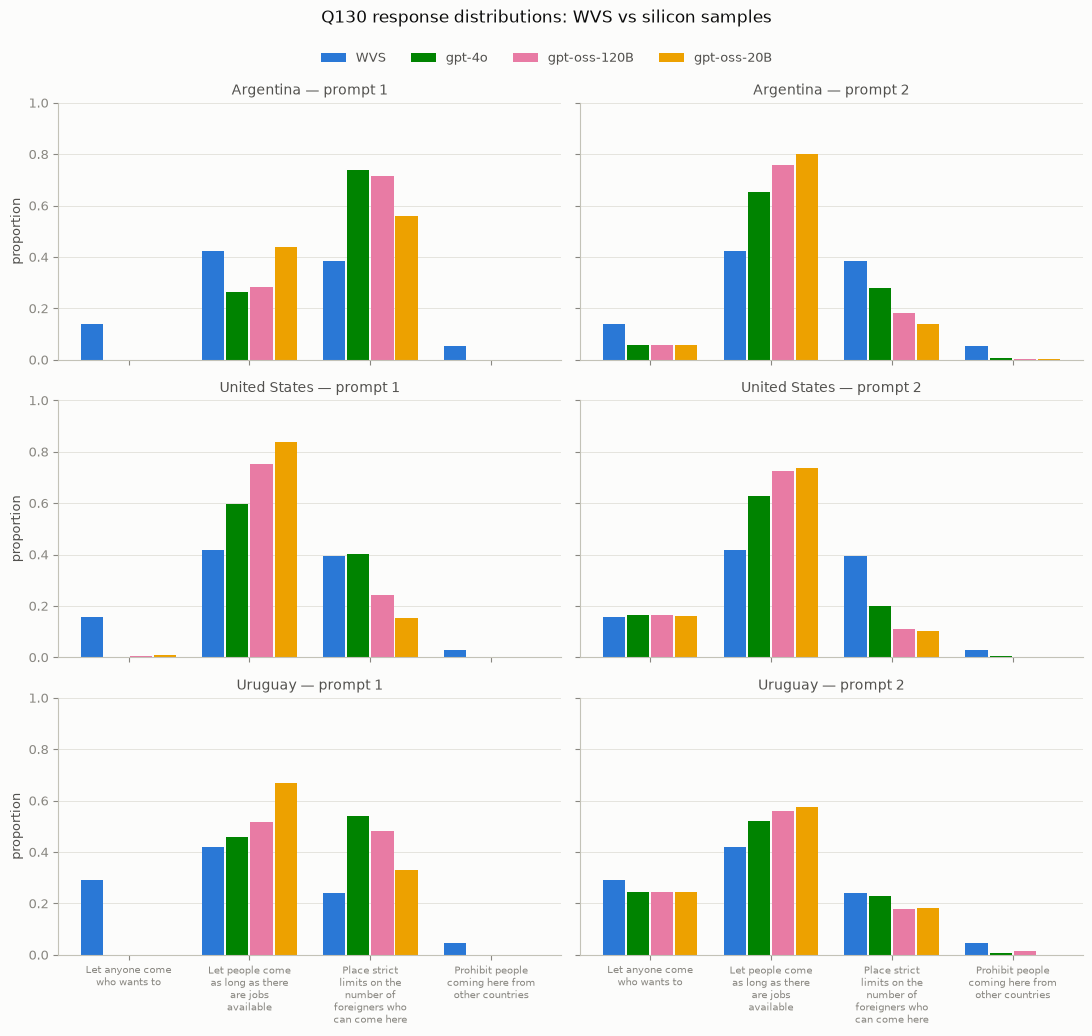

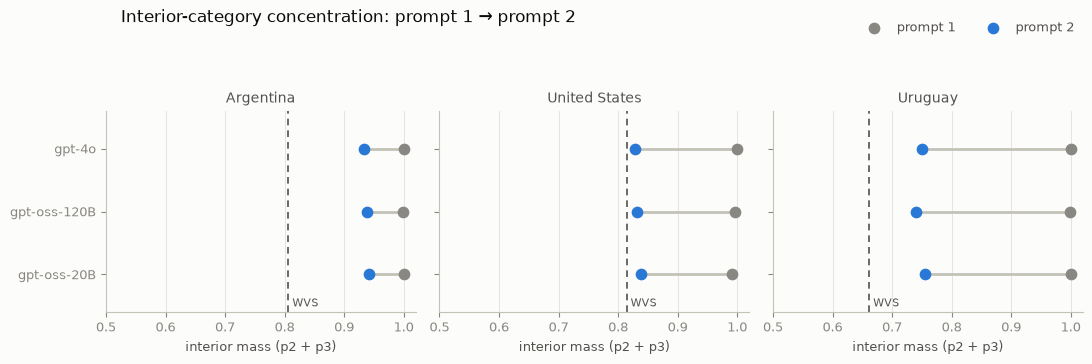

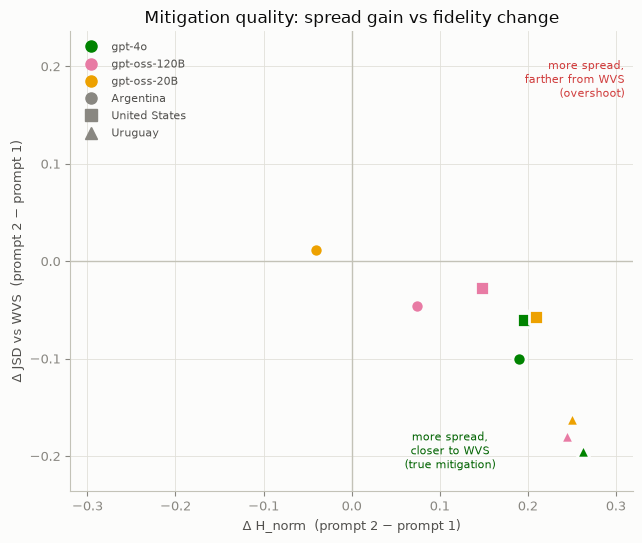

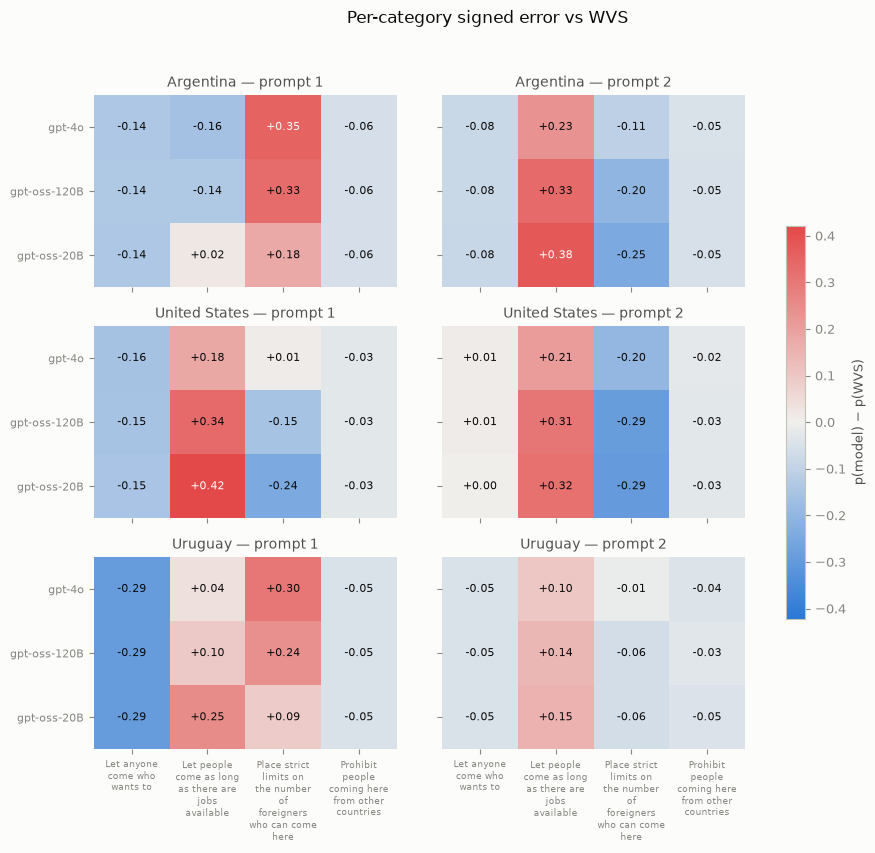

In [12]:
# -- figures ----------------------------------------------------------
fig_grouped_bars(tidy, wvs_p, m_both, countries)
fig_dumbbell(metrics, m_both, countries)
fig_scatter(paired, m_both, countries)
fig_heatmap(metrics, m_both, countries)

### Write `results/report.md`

In [13]:
def md_table(df: pd.DataFrame, floatfmt: str = "{:.3f}") -> str:
    d = df.copy()
    for c in d.columns:
        if pd.api.types.is_float_dtype(d[c]):
            d[c] = d[c].map(lambda v: "" if pd.isna(v) else floatfmt.format(v))
    header = "| " + " | ".join(d.columns) + " |"
    sep = "|" + "|".join(["---"] * len(d.columns)) + "|"
    body = "\n".join("| " + " | ".join(str(v) for v in row) + " |"
                     for row in d.values)
    return "\n".join([header, sep, body])

In [14]:
# -- report -----------------------------------------------------------
prompts_md = (IN_DIR / "prompt_examples.md").read_text()

wvs_table = pd.DataFrame({
    "country": countries,
    "H_norm (WVS)": [entropy_norm(wvs_p[c]) for c in countries],
    "IM (WVS)": [interior_mass(wvs_p[c]) for c in countries],
    "mean position (WVS)": [mean_position(wvs_p[c]) for c in countries],
    "N": [int(wvs_n[c].sum()) for c in countries],
})

disc_show = discarded[discarded.discarded_mass > 0][
    ["prompt", "model_key", "country", "discarded_n", "discarded_mass"]
].rename(columns={"model_key": "model"})

core_cols = ["prompt", "country", "model", "N_valid", "H_norm",
             "entropy_ratio", "IM", "dIM", "EM", "JSD", "W1", "mu", "dmu"]
ci_cols = ["prompt", "country", "model", "IM", "IM_lo", "IM_hi",
           "H_norm", "H_norm_lo", "H_norm_hi", "JSD", "JSD_lo", "JSD_hi"]

pooled_show = pooled.reset_index()

h3_verdicts = []
for col, alt, label in specs[:3]:
    n_ok = int(((paired[col] < 0) if alt == "less" else (paired[col] > 0)).sum())
    h3_verdicts.append((label, n_ok, len(paired)))
h3_lines = "\n".join(
    f"- **{label}** holds in {n_ok}/{n_tot} cells → "
    f"**{'SUPPORTED' if n_ok >= 0.75 * n_tot else ('MIXED' if n_ok > n_tot / 2 else 'NOT SUPPORTED')}**"
    for label, n_ok, n_tot in h3_verdicts
)

worst = disc_show.loc[disc_show.discarded_mass.idxmax()]
worst_note = (
    f"> **Caveat:** the {worst['model']} x {worst['country']} x "
    f"{worst['prompt']} cell discards {worst['discarded_mass']:.1%} of its "
    "responses as invalid. Its renormalized distribution rests on the "
    "remaining valid answers and should be read with caution wherever it "
    "appears below."
)

flags = paired[paired.overshoot_flag]

report = f"""# Middle-point bias mitigation in silicon sampling — WVS Q130

*Generated by `src/analyze_q130_bias.py` (seed 42, {N_BOOT} bootstrap reps).*

## 1. Methods

LLM-simulated ("silicon") response distributions for WVS Wave 7 Q130
(government policy toward labor immigration, 4-point ordinal scale with no
neutral midpoint) are compared against empirical WVS distributions for
Argentina, Uruguay and the United States. Because the scale has no midpoint,
middle-point bias is operationalized as **interior-category concentration**:
excess mass on the two interior categories ("{CATEGORIES[1]}" +
"{CATEGORIES[2]}"), i.e. avoidance of the extremes.

Categories outside the 4-point scale (e.g. `invalid/no answer`) were dropped
and distributions renormalized over the 4 substantive categories (discarded
mass reported in §2). All distributions sum to 1 within 1e-6 after
renormalization (asserted in code). Category order is fixed as the ordinal
vector [{"; ".join(CATEGORIES)}] at positions 1-4.

Metrics per model x country x prompt: normalized Shannon entropy
`H_norm = −Σ p·log2 p / log2 4`; entropy ratio vs WVS; interior mass
`IM = p2 + p3` and `ΔIM = IM_model − IM_WVS`; extreme mass `EM = p1 + p4`;
Jensen-Shannon divergence (base 2) vs WVS; ordinal Wasserstein-1
`W1 = Σ|CDF_model − CDF_WVS|`; per-category signed errors; mean scale
position `μ = Σ k·p_k` and `Δμ`. Per-cell response counts are available in
the inputs, so 95% multinomial bootstrap CIs (resampling both model and WVS
counts) are reported for IM, H_norm and JSD.

Paired mitigation effects (prompt 2 − prompt 1) are computed within-model,
restricted to the set `M_both` of models run under both prompts. Wilcoxon
signed-rank tests (one-sided, per hypothesis direction) with matched-pairs
rank-biserial correlation are run pooled — aggregating each model to its
mean across countries first, so no independence is assumed across the three
country cells of one model — and per country; a sign test is the robustness
check. Given n = {len(m_both)} models, effect sizes and per-model tables
carry more weight than p-values.

**Model sets.** M_both = {{{", ".join(m_both)}}}.
Models only under prompt 1: {only_p1 if only_p1 else "none"}; only under
prompt 2: {only_p2 if only_p2 else "none"}. The two prompt conditions cover
the same {len(m_both)} models, so all comparisons below are within-model and
paired; no compositionally non-comparable summaries are needed.

## 2. Data validation

WVS reference values (after keeping the 4 substantive categories):

{md_table(wvs_table)}

Discarded mass (categories outside the 4-point scale, e.g.
`invalid/no answer`), per model x country x prompt — all other cells had
zero discarded mass:

{md_table(disc_show)}

{worst_note}

## 3. Metrics

One row per model x country x prompt (full table incl. per-category signed
errors and bootstrap CIs in `results/metrics.csv`):

{md_table(metrics[core_cols])}

95% multinomial bootstrap CIs:

{md_table(metrics[ci_cols])}

## 4. H1 — Compression (entropy ratio < 1)

Cells with `H_norm(model)/H_norm(WVS) < 1`:
**prompt 1: {h1['prompt 1']}/{n_cells['prompt 1']} cells; prompt 2:
{h1['prompt 2']}/{n_cells['prompt 2']} cells.**

**Verdict: {"SUPPORTED under prompt 1" if h1['prompt 1'] >= 0.75 * n_cells['prompt 1'] else "NOT clearly supported under prompt 1"}** — LLM distributions are more
concentrated than the human WVS distributions in
{h1['prompt 1']}/{n_cells['prompt 1']} prompt-1 cells, and this persists in
{h1['prompt 2']}/{n_cells['prompt 2']} cells under prompt 2 (see H3b/H4 for
the paired change).

## 5. H2 — Interior concentration (ΔIM > 0)

Cells with `ΔIM = IM_model − IM_WVS > 0`:
**prompt 1: {h2['prompt 1']}/{n_cells['prompt 1']} cells; prompt 2:
{h2['prompt 2']}/{n_cells['prompt 2']} cells.**

**Verdict: {"SUPPORTED under prompt 1" if h2['prompt 1'] >= 0.75 * n_cells['prompt 1'] else "NOT clearly supported under prompt 1"}** — under the baseline prompt the
models pile probability onto the two interior options in
{h2['prompt 1']}/{n_cells['prompt 1']} cells (mean ΔIM =
{metrics.loc[metrics.prompt == 'prompt 1', 'dIM'].mean():+.3f} under prompt 1
vs {metrics.loc[metrics.prompt == 'prompt 2', 'dIM'].mean():+.3f} under
prompt 2).

## 6. H3 — Mitigation (paired, M_both)

Per model x country paired differences (prompt 2 − prompt 1); negative
`d_IM`, `d_JSD`, `d_W1` and positive `d_H_norm` favor mitigation:

{md_table(paired[["model", "country", "d_IM", "d_H_norm", "d_JSD", "d_W1", "dIM_p1", "dIM_p2", "ratio_p1", "ratio_p2"]])}

Pooled to one value per model (mean across the 3 countries):

{md_table(pooled_show)}

Tests (Wilcoxon signed-rank, one-sided in the hypothesized direction;
rank-biserial r; sign test = binomial on cells favoring mitigation):

{md_table(tests_df)}

Per-hypothesis cell counts (of {len(paired)} model x country cells):

{h3_lines}

With only n = {len(m_both)} models, the pooled Wilcoxon p-values cannot fall
below ~0.125 even for perfectly consistent effects; the direction counts and
rank-biserial correlations above are the primary evidence.

## 7. H4 — Overshoot check

Flagged cells (prompt 2 flips the sign of ΔIM, or pushes the entropy ratio
above 1):

{md_table(flags[["model", "country", "dIM_p1", "dIM_p2", "ratio_p1", "ratio_p2"]]) if len(flags) else "*No cells flagged.*"}

{f"**{len(flags)}/{len(paired)} cells show overcorrection** — the anti-moderation prompt does not merely restore the WVS shape there; it pushes past it (see fig. 3 quadrants for whether fidelity still improved)." if len(flags) else "No evidence of overcorrection: prompt 2 never flips interior concentration into interior avoidance, and never spreads the distribution beyond WVS entropy."}

## 8. Figures

1. `figures/fig1_distributions.png` — WVS vs model distributions per
   country, prompt 1 and prompt 2 side by side.
2. `figures/fig2_dumbbell_interior_mass.png` — interior mass per model,
   prompt 1 → prompt 2, with the WVS interior mass as reference line.
3. `figures/fig3_mitigation_quadrants.png` — Δ(H_norm) vs Δ(JSD): the
   lower-right quadrant is true mitigation (more spread *and* closer to
   WVS); the upper-right is overshoot.
4. `figures/fig4_signed_error_heatmap.png` — per-category signed errors,
   model x category, faceted by country x prompt.

## 9. Limitations

- **Few models.** n = {len(m_both)} models (one proprietary, two open-weight
  from the same family) — tests are reported but the study is descriptive;
  rank-biserial effect sizes and per-model tables are the evidence.
- **Single question, three countries.** Results speak to Q130 immigration
  attitudes in ARG/URY/USA, not to middle-point bias in general.
- **Aggregate-level analysis.** Inputs are aggregated distributions;
  response counts per cell are available and were used for multinomial
  bootstrap CIs, but no respondent-level covariate analysis is possible
  here.
- **Invalid-response mass.** The gpt-4o/US/prompt-2 cell rests on
  renormalization after discarding ~31% invalid answers; its apparent
  distribution may be selection-biased (profiles the model refuses on are
  plausibly not random).
- **Prompt confound.** Prompt 2 changes several things at once
  (first-person narrative, explicit option-by-option evaluation,
  anti-moderation instruction, and it adds a political-ideology cue to the
  profile) — effects cannot be attributed to a single ingredient.

## Appendix — prompts

{prompts_md}
"""
(RES_DIR / "report.md").write_text(report)

print(f"M_both = {m_both}")
print(f"H1: p1 {h1['prompt 1']}/{n_cells['prompt 1']}, "
      f"p2 {h1['prompt 2']}/{n_cells['prompt 2']}")
print(f"H2: p1 {h2['prompt 1']}/{n_cells['prompt 1']}, "
      f"p2 {h2['prompt 2']}/{n_cells['prompt 2']}")
for label, n_ok, n_tot in h3_verdicts:
    print(f"{label}: {n_ok}/{n_tot} cells")
print(f"H4 flags: {len(flags)}")
print("Wrote results/metrics.csv, results/paired_differences.csv, "
      "results/report.md and 4 figures.")

M_both = ['gpt-4o', 'gpt-oss-120B', 'gpt-oss-20B']
H1: p1 9/9, p2 9/9
H2: p1 9/9, p2 9/9
H3a: Δ(IM) < 0: 9/9 cells
H3b: Δ(H_norm) > 0: 8/9 cells
H3c: Δ(JSD) < 0: 8/9 cells
H4 flags: 0
Wrote results/metrics.csv, results/paired_differences.csv, results/report.md and 4 figures.
